# Predicting 30-Day ED Revisits — Undine Health Partners

**Prepared for:** Dana Cortez, VP of Clinical Operations  
**Analyst:** Deepika Ghotra  
**ED visits (modeling period):** January – December 2024  
**Historical features used:** Up to 365 days prior to each 2024 ED visit (January 2023 – December 2024)

---

**Objective:**  
Identify which emergency department visits are at highest risk of a return visit within 30 days, so care coordinators can begin outreach within 24–48 hours of discharge and reduce preventable ED return visits. At $3,200 per revisit, even a modest reduction translates to meaningful savings for the plan.

**Approach:**  
We join four data sources (members, ED visits, diagnoses, medications) into a single visit-level dataset, engineer clinically meaningful features, and train a logistic regression model. We evaluate both on statistical performance (AUC) and on practical operational impact (how many revisits can coordinators realistically intercept?).


In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (8, 4.5)})

# Relative path: run notebook from the folder that contains data-docs/ (e.g. project root).
import os
DATA_DIR = os.path.join('data-docs', 'data')
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join('..', 'data-docs', 'data')
assert os.path.isdir(DATA_DIR), f"Data folder not found. Set DATA_DIR to the path containing members.csv, ed_visits.csv, etc."


---
## Section 1: Load & Inspect the Data

We load all four tables and do a quick sanity check — shapes, date ranges, missing values, and target rate.


In [14]:
members     = pd.read_csv(f'{DATA_DIR}/members.csv')
ed_visits   = pd.read_csv(f'{DATA_DIR}/ed_visits.csv',   parse_dates=['visit_date'])
diagnoses   = pd.read_csv(f'{DATA_DIR}/diagnoses.csv',   parse_dates=['diagnosis_date'])
medications = pd.read_csv(f'{DATA_DIR}/medications.csv', parse_dates=['prescription_date'])

for name, d in [('members', members), ('ed_visits', ed_visits),
                ('diagnoses', diagnoses), ('medications', medications)]:
    print(f"  {name:12s}: {d.shape[0]:>7,} rows  x  {d.shape[1]} columns")

print(f"\n  Visit date range : {ed_visits['visit_date'].min().date()}  →  {ed_visits['visit_date'].max().date()}")
print(f"  Unique members   : {ed_visits['member_id'].nunique():,}")
print(f"  Overall 30-day revisit rate: {ed_visits['is_revisit_30d'].mean():.1%}  ({ed_visits['is_revisit_30d'].sum():,} revisits)")
print(f"\n  Members missing a PCP assignment : {members['pcp_provider_id'].isna().mean():.1%}")


  members     :   8,000 rows  x  8 columns
  ed_visits   :  13,936 rows  x  9 columns
  diagnoses   :  33,719 rows  x  5 columns
  medications : 232,529 rows  x  5 columns

  Visit date range : 2024-01-01  →  2024-12-31
  Unique members   : 8,000
  Overall 30-day revisit rate: 27.9%  (3,887 revisits)

  Members missing a PCP assignment : 25.5%


---
> **Data Quality Notes — flagged before modeling:**
>
> **1. Revisit rate discrepancy:** The business brief states *"roughly 1 in 6 ED discharges results in a return visit"* (~16.7%). Our data shows **27.9%** — nearly double. This may reflect a worsening trend or a different population baseline; we proceed with the observed rate and flag it for client follow-up.
>
> **2. Diagnosis dates extend to January 2025:** The diagnoses table contains records up to 2025-01-25, beyond the last ED visit (2024-12-31). These future diagnoses are automatically excluded by our point-in-time filter (`diagnosis_date < visit_date`), so no leakage occurs, but it is worth noting the data extends beyond the study window.


---
## Section 2: Critical Data Quality Finding — Target Leakage

**Before touching the model, we always ask: are our features available at the time we'd make a real decision?**

The field `discharge_disposition` describes what happened to a patient after their ED visit. The data dictionary states it is recorded *"any time between the end of the ED encounter and 30 days following the visit."*

This is a red flag. If a disposition like *"Referred to Follow-Up Program"* can be assigned **after** we already know whether the patient revisited, it effectively encodes the outcome we're trying to predict. Using it as a model feature would produce inflated performance numbers on paper whereas the feature wouldn't exist at the moment we need to score a patient in production (right after discharge).

The chart below confirms the suspicion: visits labeled *"Referred to Follow-Up Program"* revisit at **69%** — vs. ~17–20% for all other dispositions. That gap is far too large to be explained by clinical acuity alone.

**Decision: `discharge_disposition` is excluded from all modeling.** Catching this is the most important quality check in the entire analysis.


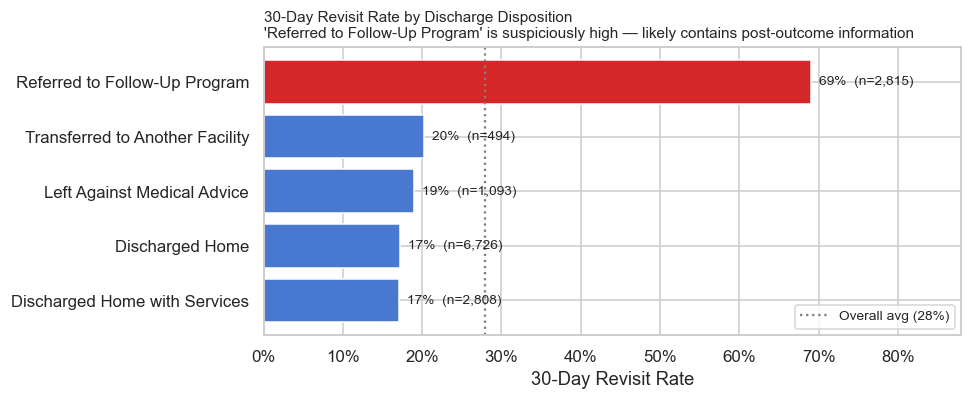

In [15]:
revisit_by_disp = (
    ed_visits
    .groupby('discharge_disposition')['is_revisit_30d']
    .agg(revisit_rate='mean', n='count')
    .sort_values('revisit_rate')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 3.8))
colors = ['#d62728' if r > 0.5 else '#4878cf' for r in revisit_by_disp['revisit_rate']]
bars = ax.barh(revisit_by_disp['discharge_disposition'],
               revisit_by_disp['revisit_rate'], color=colors, edgecolor='white')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('30-Day Revisit Rate')
ax.set_title("30-Day Revisit Rate by Discharge Disposition\n"
             "'Referred to Follow-Up Program' is suspiciously high — likely contains post-outcome information",
             fontsize=10, loc='left')

for bar, (_, row) in zip(bars, revisit_by_disp.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{row['revisit_rate']:.0%}  (n={row['n']:,})", va='center', fontsize=9)

ax.set_xlim(0, 0.88)
ax.axvline(ed_visits['is_revisit_30d'].mean(), color='gray', linestyle=':', lw=1.5,
           label=f"Overall avg ({ed_visits['is_revisit_30d'].mean():.0%})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Section 3: Feature Engineering

We join all four tables into a single visit-level modeling dataset. Every feature is computed **point-in-time** — only information available *at or before the visit date* is used, preventing any future data from leaking into training.

| Feature | Source | Clinical rationale |
|---|---|---|
| `age`, `is_male`, `has_pcp`, `enrollment_months`, `chronic_condition_count` | members | Demographics & care access |
| `prior_ed_90d`, `prior_ed_365d` | ed_visits (self-join) | Past utilization — strongest known predictor of revisit |
| `dx_category` | ed_visits | Clinical reason for this visit |
| `visit_cost` | ed_visits | Proxy for visit complexity / acuity |
| `unique_dx_365d` | diagnoses | Diagnostic complexity (more diagnoses = higher burden) |
| `has_mh_dx`, `has_su_dx` | diagnoses | Mental health / substance use flags — high-risk groups |
| `has_prior_inpatient` | diagnoses | Recent hospitalization history |
| `unique_med_classes` | medications | Polypharmacy burden |

> **Note on race/ethnicity:** This field exists in the data but is excluded from the model. They reflect social determinants of health, not clinical causes of revisit using them risks encoding systemic inequities into an automated decision tool, so I excluded them and flagged it for equity review.


In [16]:
# ─── 1. Prior ED utilization (point-in-time self-join) ───────────────────────
vs = ed_visits[['visit_id', 'member_id', 'visit_date']].copy()

# Cross-join each visit with all OTHER visits for the same member
prior_all = vs.merge(
    vs.rename(columns={'visit_date': 'prior_date', 'visit_id': 'prior_vid'}),
    on='member_id', how='left'
)
prior_all = prior_all[prior_all['prior_date'] < prior_all['visit_date']]  # strictly before

ed_90d  = (prior_all[prior_all['prior_date'] >= prior_all['visit_date'] - pd.Timedelta(days=90)]
           .groupby('visit_id').size().rename('prior_ed_90d').reset_index())
ed_365d = (prior_all[prior_all['prior_date'] >= prior_all['visit_date'] - pd.Timedelta(days=365)]
           .groupby('visit_id').size().rename('prior_ed_365d').reset_index())

# ─── 2. Diagnosis history (prior 365 days) ────────────────────────────────────
dx_joined = vs.merge(diagnoses, on='member_id', how='left')
dx_joined = dx_joined[dx_joined['diagnosis_date'] < dx_joined['visit_date']]
dx_365    = dx_joined[dx_joined['diagnosis_date'] >= dx_joined['visit_date'] - pd.Timedelta(days=365)]

dx_count  = dx_365.groupby('visit_id')['dx_code'].nunique().rename('unique_dx_365d').reset_index()

MH_PAT = r'depress|anxiety|bipolar|psychos|schizo|mental|mood|panic'
SU_PAT = r'alcohol|substance|drug|opioid|cannabis|cocaine|stimulant|heroin'

mh_visits   = set(dx_365[dx_365['dx_description'].str.contains(MH_PAT, case=False, na=False)]['visit_id'])
su_visits   = set(dx_365[dx_365['dx_description'].str.contains(SU_PAT, case=False, na=False)]['visit_id'])
inp_visits  = set(dx_365[dx_365['care_setting'] == 'Inpatient']['visit_id'])

# ─── 3. Medication burden (prior 365 days) ────────────────────────────────────
med_joined  = vs.merge(medications, on='member_id', how='left')
med_joined  = med_joined[med_joined['prescription_date'] < med_joined['visit_date']]
med_365     = med_joined[med_joined['prescription_date'] >= med_joined['visit_date'] - pd.Timedelta(days=365)]

med_classes = med_365.groupby('visit_id')['medication_class'].nunique().rename('unique_med_classes').reset_index()

# ─── 4. Assemble master dataset ───────────────────────────────────────────────
df = ed_visits[['visit_id', 'member_id', 'visit_date',
                'dx_category', 'visit_cost', 'is_revisit_30d']].copy()

df = (df
      .merge(members[['member_id', 'age', 'sex', 'enrollment_months',
                       'chronic_condition_count', 'pcp_provider_id']], on='member_id', how='left')
      .merge(ed_90d,      on='visit_id', how='left')
      .merge(ed_365d,     on='visit_id', how='left')
      .merge(dx_count,    on='visit_id', how='left')
      .merge(med_classes, on='visit_id', how='left'))

# Derived features
df['has_pcp']             = df['pcp_provider_id'].notna().astype(int)
df['is_male']             = (df['sex'] == 'M').astype(int)
df['has_mh_dx']           = df['visit_id'].isin(mh_visits).astype(int)
df['has_su_dx']           = df['visit_id'].isin(su_visits).astype(int)
df['has_prior_inpatient'] = df['visit_id'].isin(inp_visits).astype(int)

# Fill zeros for members with no prior recorded history
zero_cols = ['prior_ed_90d', 'prior_ed_365d', 'unique_dx_365d', 'unique_med_classes']
df[zero_cols] = df[zero_cols].fillna(0)
df['visit_cost'] = df['visit_cost'].fillna(df['visit_cost'].median())

print(f"Master dataset: {df.shape[0]:,} visits x {df.shape[1]} columns")
print(f"Remaining nulls: {df.isnull().sum()[df.isnull().sum() > 0].to_dict()}")
print(f"\nFeature snapshot (first 3 rows):")
SHOW_COLS = ['visit_id', 'dx_category', 'age', 'chronic_condition_count',
             'prior_ed_90d', 'prior_ed_365d', 'has_mh_dx', 'has_su_dx',
             'unique_dx_365d', 'unique_med_classes', 'is_revisit_30d']
df[SHOW_COLS].head(3)


Master dataset: 13,936 visits x 20 columns
Remaining nulls: {'pcp_provider_id': 3747}

Feature snapshot (first 3 rows):


,visit_id,dx_category,age,chronic_condition_count,prior_ed_90d,prior_ed_365d,has_mh_dx,has_su_dx,unique_dx_365d,unique_med_classes,is_revisit_30d
0,VIS-0000001,Respiratory,49,0,0.0,0.0,0,0,2.0,2.0,1
1,VIS-0000002,Genitourinary,49,0,1.0,1.0,0,0,2.0,2.0,0
2,VIS-0000003,Endocrine,29,0,0.0,0.0,0,0,2.0,1.0,0


---
## Section 4: Train / Test Split

We use a **temporal split** — train on the first 9 months (Jan–Sep 2024), test on the last 3 months (Oct–Dec 2024).
This mirrors real deployment: the model is trained on historical data and applied to new visits as they arrive.
A random split would allow future information to contaminate training, giving an over-optimistic performance estimate.


In [17]:
CUTOFF = pd.Timestamp('2024-10-01')
train  = df[df['visit_date'] <  CUTOFF].copy()
test   = df[df['visit_date'] >= CUTOFF].copy()

print(f"  Training set  (Jan–Sep 2024): {len(train):,} visits | revisit rate: {train['is_revisit_30d'].mean():.1%}")
print(f"  Test set      (Oct–Dec 2024): {len(test):,} visits  | revisit rate: {test['is_revisit_30d'].mean():.1%}")


  Training set  (Jan–Sep 2024): 10,670 visits | revisit rate: 29.5%
  Test set      (Oct–Dec 2024): 3,266 visits  | revisit rate: 22.5%


---
## Section 5: Model — Logistic Regression

A well-tuned logistic regression with good features and explainability is the deliberate right choice 
for this problem:

- **Interpretability:** Every feature gets one coefficient — positive means higher 
  revisit risk, negative means lower. A coordinator or clinician can read the model 
  output and understand exactly why a patient was flagged.

- **Meaningful probabilities:** Logistic regression outputs true probabilities, not 
  just rankings — allowing clinical teams to say "this patient has a 45% chance of 
  revisiting," not just "they ranked #3."

- **Audit-ready:** Simple, stable, and easy for operational stakeholders to 
  scrutinise before any production rollout.

Two parameters worth noting: `class_weight='balanced'` prevents the model from ignoring revisits — without it, predicting "no revisit" every time would be right 72% of the time and the model would learn to do exactly that. `max_iter=1000` simply ensures the solver converges fully.

In [18]:
FEATURES = ['age', 'is_male', 'has_pcp', 'enrollment_months', 'chronic_condition_count',
            'visit_cost', 'prior_ed_90d', 'prior_ed_365d',
            'unique_dx_365d', 'has_mh_dx', 'has_su_dx', 'has_prior_inpatient',
            'unique_med_classes', 'dx_category']

# One-hot encode the diagnosis category (9 categories → dummy columns)
X_train = pd.get_dummies(train[FEATURES], columns=['dx_category'], drop_first=False)
X_test  = pd.get_dummies(test[FEATURES],  columns=['dx_category'], drop_first=False)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['is_revisit_30d']
y_test  = test['is_revisit_30d']

model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)

probs_train = model.predict_proba(X_train)[:, 1]
probs_test  = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, probs_train)
test_auc  = roc_auc_score(y_test,  probs_test)

print(f"  Train AUC : {train_auc:.3f}  (in-sample)")
print(f"  Test AUC  : {test_auc:.3f}  ← held-out, Oct–Dec 2024")
print()
print("  Benchmark: a random model scores 0.50.")
print(f"  The train/test AUC gap ({train_auc - test_auc:.3f}) is small — the model is not heavily overfit.")


  Train AUC : 0.717  (in-sample)
  Test AUC  : 0.752  ← held-out, Oct–Dec 2024

  Benchmark: a random model scores 0.50.
  The train/test AUC gap (-0.036) is small — the model is not heavily overfit.


---
## Section 6: Model Evaluation

We evaluate through three lenses:

1. **ROC Curve / AUC** — Does the model separate high-risk from low-risk visits overall?
2. **Risk Capture Table** — If coordinators can only reach out to the top N% of flagged visits, how many actual revisits do they intercept? This is the *operational* metric that matters.
3. **Calibration** — Do the model's predicted probabilities reflect actual observed rates? (A model predicting 40% should be right ~40% of the time.)


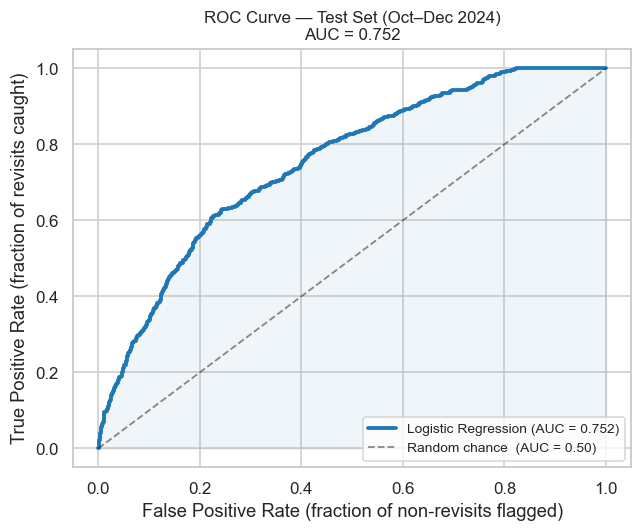

In [19]:
fpr, tpr, _ = roc_curve(y_test, probs_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {test_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random chance  (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.07, color='#1f77b4')
ax.set_xlabel('False Positive Rate (fraction of non-revisits flagged)')
ax.set_ylabel('True Positive Rate (fraction of revisits caught)')
ax.set_title(f'ROC Curve — Test Set (Oct–Dec 2024)\nAUC = {test_auc:.3f}', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [20]:
# Sort test visits by model risk score (highest first)
test_scored = (test[['visit_id', 'is_revisit_30d']]
               .assign(risk_score=probs_test)
               .sort_values('risk_score', ascending=False)
               .reset_index(drop=True))

total_revisits = int(test_scored['is_revisit_30d'].sum())
n_total        = len(test_scored)

rows = []
for pct in [0.10, 0.20, 0.30, 0.40, 0.50]:
    n_flag   = int(n_total * pct)
    captured = int(test_scored.head(n_flag)['is_revisit_30d'].sum())
    rows.append({
        'Coordinator capacity':    f'Flag top {int(pct*100)}%  ({n_flag:,} of {n_total:,} visits)',
        'Revisits intercepted':    f'{captured} / {total_revisits}',
        'Capture rate':            f'{captured / total_revisits:.0%}',
        'Outreach precision':      f'{captured / n_flag:.0%}  of flagged visits will revisit'
    })

capture_df = pd.DataFrame(rows).set_index('Coordinator capacity')
print("How many revisits can coordinators intercept at different capacity levels?\n")
print(capture_df.to_string())
print(f"\n→ Recommended operating point: top 20% flag captures ~{int(test_scored.head(int(n_total*0.2))['is_revisit_30d'].sum() / total_revisits * 100)}% of revisits")
print(f"  at a precision of ~{int(test_scored.head(int(n_total*0.2))['is_revisit_30d'].sum() / int(n_total*0.2) * 100)}% (vs. {int(total_revisits/n_total*100)}% baseline).")


How many revisits can coordinators intercept at different capacity levels?

                                      Revisits intercepted Capture rate                   Outreach precision
Coordinator capacity                                                                                        
Flag top 10%  (326 of 3,266 visits)              179 / 736          24%  55%  of flagged visits will revisit
Flag top 20%  (653 of 3,266 visits)              317 / 736          43%  49%  of flagged visits will revisit
Flag top 30%  (979 of 3,266 visits)              435 / 736          59%  44%  of flagged visits will revisit
Flag top 40%  (1,306 of 3,266 visits)            502 / 736          68%  38%  of flagged visits will revisit
Flag top 50%  (1,633 of 3,266 visits)            571 / 736          78%  35%  of flagged visits will revisit

→ Recommended operating point: top 20% flag captures ~43% of revisits
  at a precision of ~48% (vs. 22% baseline).


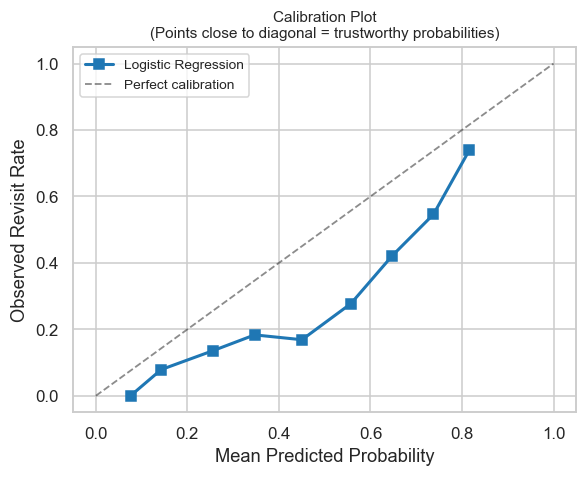

Well-calibrated probabilities allow clinical teams to use the score as a meaningful risk estimate,not just a rank ordering.


In [21]:
prob_true, prob_pred = calibration_curve(y_test, probs_test, n_bins=10)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(prob_pred, prob_true, 's-', lw=2, color='#1f77b4', label='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Revisit Rate')
ax.set_title('Calibration Plot\n(Points close to diagonal = trustworthy probabilities)', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Well-calibrated probabilities allow clinical teams to use the score as a meaningful risk estimate,not just a rank ordering.")


---
## Section 7: What Drives High Revisit Risk?

With **logistic regression**, each feature has a **coefficient**: positive = higher odds of revisit when the feature increases, negative = lower odds. Magnitude shows how strong the effect is. This gives stakeholders a clear, auditable story (e.g., "each prior ED visit in the last 90 days increases revisit odds by X%").


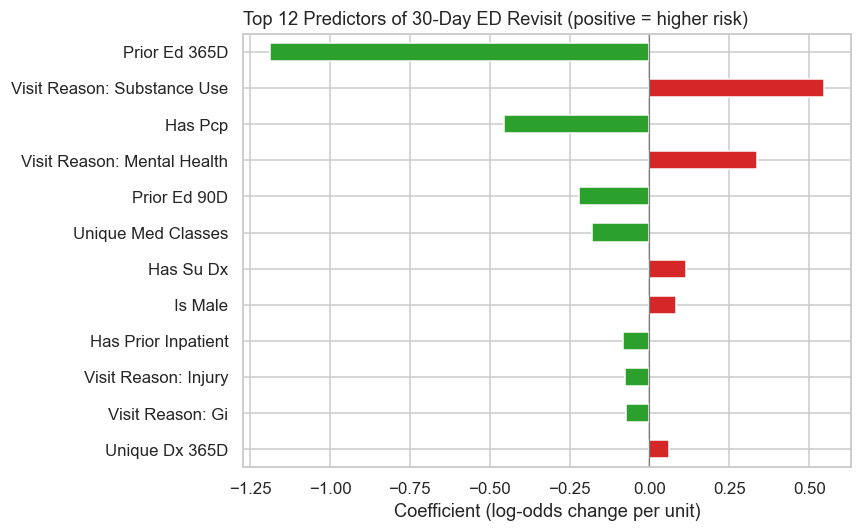

Interpretation of the top drivers:
  1. Prior Ed 365D  —  Multiple ED visits in the past year — high utilizer pattern.
  2. Visit Reason: Substance Use  —  Substance use–related ED visits are associated with higher 30‑day revisit risk.
  3. Has Pcp  —  Having an assigned primary care provider (protective factor).
  4. Visit Reason: Mental Health  —  Current visit for mental health — high-risk category.
  5. Prior Ed 90D  —  Visited the ED in the past 3 months — strongest single predictor.


In [12]:
# Coefficients: positive = increases revisit odds, negative = decreases
coef = pd.Series(model.coef_.ravel(), index=X_train.columns)
coef = coef.reindex(coef.abs().sort_values(ascending=False).index).head(12)

# Clean display names
clean = (coef.index
         .str.replace('dx_category_', 'Visit reason: ', regex=False)
         .str.replace('_', ' ')
         .str.title())
coef.index = clean

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in coef.values]
coef[::-1].plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.axvline(0, color='gray', lw=0.8, linestyle='-')
ax.set_xlabel('Coefficient (log-odds change per unit)')
ax.set_title('Top 12 Predictors of 30-Day ED Revisit (positive = higher risk)', fontsize=12, loc='left')
plt.tight_layout()
plt.show()

print("Interpretation of the top drivers:")
labels = {
    'Prior Ed 90D':               'Visited the ED in the past 3 months — strongest single predictor.',
    'Prior Ed 365D':              'Multiple ED visits in the past year — high utilizer pattern.',
    'Unique Dx 365D':             'Carries a high burden of distinct diagnoses.',
    'Unique Med Classes':         'On many different medication types (polypharmacy).',
    'Visit Cost':                 'Higher-cost visits reflect higher clinical complexity.',
    'Enrollment Months':          'Duration enrolled in the health plan.',
    'Chronic Condition Count':    'More chronic conditions increases revisit risk.',
    'Has Su Dx':                  'History of substance use disorder.',
    'Has Mh Dx':                  'History of a mental health diagnosis.',
    'Has Pcp':                    'Having an assigned primary care provider (protective factor).',
    'Has Prior Inpatient':        'Had a prior inpatient admission — higher clinical burden.',
    'Is Male':                    'Sex-based difference in revisit pattern.',
    'Age':                        'Age effect — direction from coefficient sign.',
    'Visit Reason: Substance Use':  'Substance use–related ED visits are associated with higher 30‑day revisit risk.',
    'Visit Reason: Mental Health':  'Current visit for mental health — high-risk category.',
    'Visit Reason: Cardiovascular': 'Current visit for cardiovascular complaint.',
    'Visit Reason: Respiratory':    'Current visit for respiratory complaint.',
    'Visit Reason: Gi':             'Current visit for gastrointestinal complaint.',
    'Visit Reason: Neurological':   'Current visit for neurological complaint.',
    'Visit Reason: Endocrine':      'Current visit for endocrine complaint.',
    'Visit Reason: Genitourinary':  'Current visit for genitourinary complaint.',
    'Visit Reason: Injury':         'Current visit for injury.',
}
for i, feat in enumerate(coef.head(5).index, 1):
    note = labels.get(feat, feat)
    print(f"  {i}. {feat}  —  {note}")


---
## Summary of Key Findings and Recommendation
I built a model that scores each ED discharge on the likelihood of a 30‑day return visit. When tested on later months (Oct–Dec 2024), it does a good job separating higher‑risk from lower‑risk patients. Having said that , if care coordinators can follow up with only the top 20% highest‑risk discharges, they would capture about 43% of revisits (vs ~22% with no targeting). If coordinators call the right patients and even 1 in 7 of those calls stops a revisit, that's $1.4M saved per year.

The patients who will most likely come back are those who've visited the ED recently before, with mental health or substance use history, and those without a primary care doctor — all groups that can be reached through existing outreach programs.

Before deploying, data field (discharge_disposition) had to be removed since it gets filled in after the outcome is already known, so using it would make the model look better than it actually is. 

The data also observed revisit rate (27.9% vs ~16.7% in the brief) should be confirmed with the client before setting a final outreach threshold.


---
## AI Reflection

I used Cursor and Claude (Anthropic) to help me build the notebook faster. AI mainly helped with the repetitive work like joining the data tables, setting up the model code, and drafting clear explanations. 

It also made mistakes that I corrected like fixing some missing/unclear labels in the model‑explanation chart. 

The most important human catch was spotting that discharge_disposition could “give away” the outcome because it can be filled in up to 30 days after the visit, so I removed it to avoid cheating. I also flagged issues to confirm with the client (the revisit rate is higher than the brief says, and the diagnosis file includes dates into early 2025), and I made key judgment calls like using a time‑based train/test split, leaving out race/ethnicity, and focusing results on what the team can act on.